#  Fraudulent Transactions Data Analysis
##  Exploratory Data Analysis (EDA) & Data Preparation

###  Methodology: CRISP-DM Framework
This project is structured based on the **Cross-Industry Standard Process for Data Mining (CRISP-DM)** framework to ensure a comprehensive and business-aligned approach to fraud detection. 

This specific notebook covers the first three phases of the methodology:

1. **Define the business problem.**
2. **Collect the data and get a general overview of it.**
3. **Split the data into train and test sets.**
4. **Explore the data (exploratory data analysis).**
5. **Data cleaning and preprocessing.**
6. **Model training, comparison, selection and tuning.**
7. **Final production model testing and evaluation.**
8. **Conclude and interpret the model results.**
9. **Deploy.**


In [38]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    average_precision_score, roc_auc_score, classification_report,
    precision_recall_curve, confusion_matrix
)

from imblearn.pipeline import Pipeline as ImbPipeline   # NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

RANDOM_STATE = 42
DATA_PATH = '/data/PROJETOS/ALURA-FRAUDE/data/Fraud.csv'

TEST_QUANTILE   = 0.80   
VAL_QUANTILE    = 0.80   
SEARCH_FRACTION = 0.15  
N_TRIALS        = 40

optuna.logging.set_verbosity(optuna.logging.WARNING)


RANDOM_STATE = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/data/PROJETOS/ALURA-FRAUDE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## DATASET

In [3]:
df = pl.read_csv('/data/PROJETOS/ALURA-FRAUDE/data/Fraud.csv')

df.head()

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
i64,str,f64,str,f64,f64,str,f64,f64,i64,i64
1,"""PAYMENT""",9839.64,"""C1231006815""",170136.0,160296.36,"""M1979787155""",0.0,0.0,0,0
1,"""PAYMENT""",1864.28,"""C1666544295""",21249.0,19384.72,"""M2044282225""",0.0,0.0,0,0
1,"""TRANSFER""",181.0,"""C1305486145""",181.0,0.0,"""C553264065""",0.0,0.0,1,0
1,"""CASH_OUT""",181.0,"""C840083671""",181.0,0.0,"""C38997010""",21182.0,0.0,1,0
1,"""PAYMENT""",11668.14,"""C2048537720""",41554.0,29885.86,"""M1230701703""",0.0,0.0,0,0


In [39]:
df = (
    pl.read_csv(DATA_PATH)
    .with_columns([
        (pl.col('oldbalanceOrg') - pl.col('amount') - pl.col('newbalanceOrig')).alias('errorBalanceOrig'),
        (pl.col('oldbalanceDest') + pl.col('amount') - pl.col('newbalanceDest')).alias('errorBalanceDest'),
        pl.col('nameDest').str.starts_with('M').cast(pl.Int8).alias('is_merchant_dest'),
        (pl.col('step') % 24).alias('hour_of_day'),
        ((pl.col('step') // 24) % 7).alias('day_of_week'),
    ])
    .drop(['isFlaggedFraud'])          # rules-engine output -> direct label leakage
    .sort('step')                      # chronological order is load-bearing from here on
)


TARGET = 'isFraud'

REALTIME_FEATURES = [
    'type', 'amount', 'oldbalanceOrg', 'oldbalanceDest',
    'is_merchant_dest', 'hour_of_day', 'day_of_week',
]

FORENSIC_FEATURES = REALTIME_FEATURES + [
    'newbalanceOrig', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest',
]

CATEGORICAL = ['type']

## SPLIT DATA INTO TRAIN AND TEST

In [40]:
cut_test = df.select(pl.col('step').quantile(TEST_QUANTILE)).item()
df_dev, df_test = df.filter(pl.col('step') <= cut_test), df.filter(pl.col('step') > cut_test)

cut_val = df_dev.select(pl.col('step').quantile(VAL_QUANTILE)).item()
df_train, df_val = df_dev.filter(pl.col('step') <= cut_val), df_dev.filter(pl.col('step') > cut_val)


def to_xy(frame: pl.DataFrame, features: list[str]):
    """polars -> pandas. sklearn/imblearn handle pandas reliably; polars output is
    not supported by the resamplers."""
    X = frame.select(features).to_pandas()
    y = frame.select(TARGET).to_pandas()[TARGET].to_numpy().ravel()
    return X, y


for name, frame in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    n, k = frame.height, frame.select(pl.col(TARGET).sum()).item()
    print(f"{name:<6} steps {frame['step'].min():>4}-{frame['step'].max():>4} | "
          f"{n:>9,} rows | {k:>6,} frauds ({k / n:.4%})")

TRAIN  steps    1- 301 | 4,104,531 rows |  3,405 frauds (0.0830%)
VAL    steps  302- 355 | 1,009,353 rows |    558 frauds (0.0553%)
TEST   steps  356- 743 | 1,248,736 rows |  4,250 frauds (0.3403%)


# **5. DATA CLEANING PROCESS**

In [41]:
def build_preprocessor(features: list[str], scale: bool) -> ColumnTransformer:
    numeric = [c for c in features if c not in CATEGORICAL]
    return ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
            ('num', StandardScaler() if scale else 'passthrough', numeric),
        ],
        remainder='drop',
    )


def build_pipeline(model, features, balance='smote', scale=False, smote_k=5):
    """Resampling lives INSIDE the pipeline, so it is re-fitted on each training
    fold and never sees the validation fold."""
    steps = [('preprocessor', build_preprocessor(features, scale))]
    if balance == 'smote':
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)))
    steps.append(('model', model))
    return ImbPipeline(steps)


def pr_auc_cv(pipeline, X, y, n_splits=3) -> float:
    """Forward-chaining CV: every validation fold is strictly later than its training
    folds. average_precision (PR-AUC) is the right headline metric at 0.13% prevalence
    — ROC-AUC stays flattering when negatives dominate."""
    scores = cross_val_score(
        pipeline, X, y,
        cv=TimeSeriesSplit(n_splits=n_splits),
        scoring='average_precision',
        n_jobs=1,
    )
    return scores.mean(), scores.std()

In [42]:
# Screening and tuning run on a stratified subsample of TRAIN. Stratifying by the
# target preserves the 0.13% prevalence, so PR-AUC stays on the same scale as the
# full data; sorting by step preserves the ordering TimeSeriesSplit depends on.
df_search = (
    df_train
    .with_columns(pl.int_range(pl.len()).shuffle(seed=RANDOM_STATE).over(TARGET).alias('_r'),
                  pl.len().over(TARGET).alias('_n'))
    .filter(pl.col('_r') < (pl.col('_n') * SEARCH_FRACTION).ceil())
    .drop(['_r', '_n'])
    .sort('step')
)

X_search, y_search = to_xy(df_search, FORENSIC_FEATURES)
print(f"Search sample: {len(y_search):,} rows | {y_search.sum():,} frauds ({y_search.mean():.4%})")

Search sample: 615,680 rows | 511 frauds (0.0830%)


# **6. Model training, comparison, selection and tuning**

In [43]:
POS_WEIGHT = (y_search == 0).sum() / max((y_search == 1).sum(), 1)

models_to_run = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    'Decision Tree':       (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), False),
    'XGBoost':             (XGBClassifier(tree_method='hist', eval_metric='aucpr',
                                          random_state=RANDOM_STATE, n_jobs=-1), False),
}

results = {}
for name, (model, needs_scaling) in models_to_run.items():
    start = time.time()
    pipe = build_pipeline(model, FORENSIC_FEATURES, balance='smote', scale=needs_scaling)
    mean_ap, std_ap = pr_auc_cv(pipe, X_search, y_search)
    results[name] = {'PR-AUC (CV)': mean_ap, 'Std': std_ap, 'Fit time (s)': time.time() - start}
    print(f"{name:<22} PR-AUC {mean_ap:.4f} (+/- {std_ap:.4f})  [{results[name]['Fit time (s)']:.1f}s]")

df_results = pd.DataFrame(results).T
display(df_results)

Logistic Regression    PR-AUC 0.6404 (+/- 0.0434)  [8.1s]
Decision Tree          PR-AUC 0.6697 (+/- 0.2649)  [5.9s]
Random Forest          PR-AUC 0.9884 (+/- 0.0102)  [79.7s]
XGBoost                PR-AUC 0.9693 (+/- 0.0233)  [6.6s]


,PR-AUC (CV),Std,Fit time (s)
Logistic Regression,0.640402,0.043432,8.112532
Decision Tree,0.669665,0.264867,5.860218
Random Forest,0.988440,0.010207,79.738368
XGBoost,0.969267,0.023335,6.569039


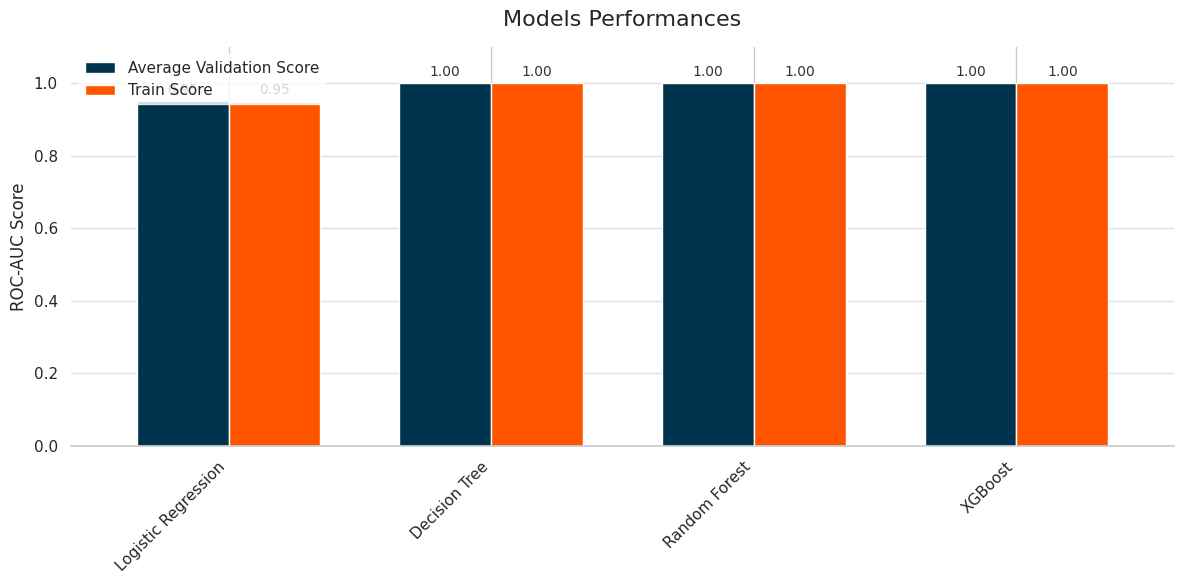

In [44]:
df_resultados = pd.DataFrame(resultados_modelos).T.reset_index()

df_resultados.rename(columns={'index': 'Model'}, inplace=True)

df_plot = df_resultados.set_index('Model')[['Average validation score', 'Training score']]

fig, ax = plt.subplots(figsize=(12, 6))

cores = ['#00334e', '#ff5500'] 

df_plot.plot(
    kind='bar', 
    ax=ax, 
    color=cores, 
    width=0.7, 
    edgecolor='white'
)

ax.set_title('Models Performances', fontsize=16, pad=15)
ax.set_ylabel('ROC-AUC Score', fontsize=12) # Conforme está no eixo Y da imagem
ax.set_xlabel('')

ax.set_ylim(0, 1.1)

ax.grid(axis='y', color='lightgrey', linestyle='-', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.xticks(rotation=45, ha='right')

ax.legend(['Average Validation Score', 'Train Score'], loc='upper left', frameon=True, edgecolor='white')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10, color='#333333')

plt.tight_layout()
plt.show()

In [45]:
def objective(trial: optuna.Trial) -> float:
    balance = trial.suggest_categorical('balance', ['smote', 'scale_pos_weight'])

    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 900, step=100),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 20.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
    }

    if balance == 'scale_pos_weight':
        params['scale_pos_weight'] = trial.suggest_float(
            'scale_pos_weight', 0.1 * POS_WEIGHT, 2.0 * POS_WEIGHT, log=True
        )
        smote_k = 5
    else:
        smote_k = trial.suggest_int('smote_k_neighbors', 3, 10)

    model = XGBClassifier(
        **params, tree_method='hist', eval_metric='aucpr',
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    pipe = build_pipeline(
        model, FORENSIC_FEATURES,
        balance='smote' if balance == 'smote' else 'none',
        smote_k=smote_k,
    )

    mean_ap, _ = pr_auc_cv(pipe, X_search, y_search, n_splits=3)
    return mean_ap


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='xgb_fraud_pr_auc',
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest CV PR-AUC: {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 6. Best value: 0.990548: 100%|██████████| 40/40 [11:35<00:00, 17.38s/it]


Best CV PR-AUC: 0.9905
  balance: scale_pos_weight
  n_estimators: 700
  max_depth: 8
  learning_rate: 0.13780336485751998
  subsample: 0.6296178606936361
  colsample_bytree: 0.6792328642721364
  min_child_weight: 3
  gamma: 4.315517129377968
  reg_lambda: 0.4795390071049124
  reg_alpha: 0.021066486017042207
  scale_pos_weight: 145.63469887149677


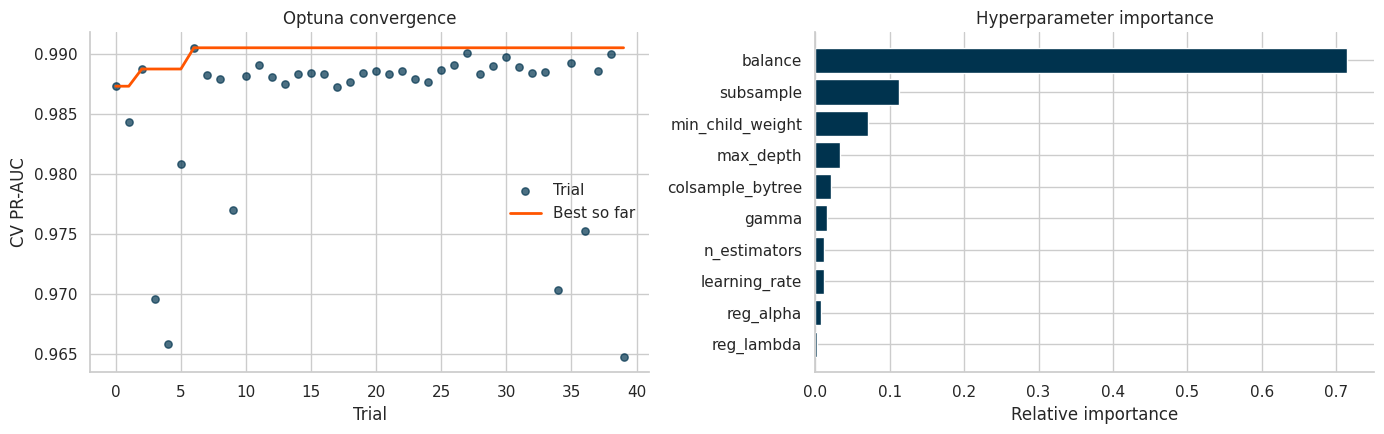

In [46]:
history = pd.DataFrame([
    {'trial': t.number, 'pr_auc': t.value, 'balance': t.params.get('balance')}
    for t in study.trials if t.value is not None
])
history['best_so_far'] = history['pr_auc'].cummax()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].scatter(history['trial'], history['pr_auc'], s=28, color='#00334e', alpha=0.7, label='Trial')
axes[0].plot(history['trial'], history['best_so_far'], color='#ff5500', lw=2, label='Best so far')
axes[0].set(title='Optuna convergence', xlabel='Trial', ylabel='CV PR-AUC')
axes[0].legend(frameon=False)

try:
    importance = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importance)[::-1], list(importance.values())[::-1], color='#00334e')
    axes[1].set(title='Hyperparameter importance', xlabel='Relative importance')
except RuntimeError:
    # Raised when every trial returns the same score. If this fires, the objective is
    # not discriminating between configurations — usually a sign that leakage is still
    # present somewhere, or that the metric is saturated.
    axes[1].text(0.5, 0.5, 'Zero variance across trials', ha='center', va='center')
    axes[1].set_axis_off()

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()